In [1]:
%run ../scripts/notebook_settings.py
import sgkit as sg
import xarray as xr
import glob

In [2]:
from skbio import DistanceMatrix
from skbio.tree import nj
from skbio.tree import upgma
from skbio.tree import bme
from skbio import TreeNode

Pruning the tree so it only has the species of interest.

In [3]:
primate_tree = TreeNode.read("../data/Craig_Kumar_Hedges_final_timetree.nwk")
primate_tree

<TreeNode, name: unnamed, internal node count: 453, tips count: 455>

In [4]:
table_desc = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/plots/SupTable_Sample_Stats_wGT_QC.tsv"
metadata_path = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/"

metadata_table = pd.read_csv(table_desc, sep="\t")

metadata_20x_filt = metadata_table.loc[(metadata_table.finalQC != "fail")
                              & (metadata_table.cov_chrA >= 20)
                              & (metadata_table.remove_as_relative != True)
                              & (metadata_table.remove_manual != True)
                              & (~metadata_table.ID.str.startswith("SAMEA11633"))
                             ]

In [5]:
df_l = []
for s in metadata_20x_filt.species_genotyping.unique():
    f_c = len(metadata_20x_filt.loc[metadata_20x_filt.gSEX == "F"])
    if f_c == 0:
        continue
    # Read het df
    pi_df_path = "../results/window_stats_20x_inds/{}_100kb_pi.txt".format(s)
    if os.path.exists("../results/window_stats_20x_inds/{}_100kb_pi.txt".format(s)):
        pi_df = pd.read_csv(pi_df_path, sep="\t")
    else:
        print("Not present:", s)
        continue
    df_l.append(pi_df)
all_pi_df = pd.concat(df_l)

In [6]:
# Credit to Vasili Pankratov for consolidating this data
mating_vas = pd.read_excel("../data/PrimatePhenotypes_december.xlsx", sheet_name=8)
mating_vas

,binomial_name,Monogamous,Polygynous,Polygynandrous,Polyandrous,lowSC,highSC,consensus,comment,Juliana_Christina,genus_comment
0,Allenopithecus_nigroviridis,0,0,1,0,0,1,Polygynandrous,NaN,NaN,NaN
1,Allocebus_trichotis,2,1,0,0,3,0,Monogamous,NaN,NaN,NaN
2,Allochrocebus_lhoesti,0,3,0,0,3,0,Polygynous,NaN,NaN,NaN
3,Allochrocebus_preussi,0,1,0,0,1,0,Polygynous,NaN,NaN,NaN
4,Allochrocebus_solatus,0,1,0,0,1,0,Polygynous,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
311,Trachypithecus_phayrei,0,2,1,0,2,1,NaN,conflicting,NaN,NaN
312,Trachypithecus_pileatus,0,2,0,0,2,0,Polygynous,NaN,NaN,NaN
313,Trachypithecus_selangorensis,0,1,0,0,1,0,Polygynous,NaN,NaN,NaN
314,Varecia_rubra,0,1,1,0,1,1,NaN,conflicting,NaN,NaN


In [7]:
mean_pi_df = all_pi_df.loc[all_pi_df.callable_frac >= 0.75].groupby(["species","chr_type"])[["pi"]].mean()
mean_pi_df = mean_pi_df.reset_index().pivot(columns="chr_type", index="species", values="pi")
all_pi_df_aut = all_pi_df.loc[all_pi_df.chr_type == "aut"]
mean_pi_df = mean_pi_df.reset_index()
mean_pi_df["CV_aut"] = (all_pi_df_aut.groupby(["species"])[["pi"]].std() / all_pi_df_aut.groupby(["species"])[["pi"]].mean()).reset_index()["pi"]
mean_pi_df["Autosomal Pi per base"] = mean_pi_df.aut/100000
mean_pi_df["ChrX Pi per base"] = mean_pi_df.chrX/100000
mean_pi_df["X_a_ratio"] = mean_pi_df.chrX/mean_pi_df.aut
mean_pi_df["X/A ratio"] = mean_pi_df.chrX/mean_pi_df.aut
mean_pi_df["binomial_name"] = [x[:-4] for x in mean_pi_df.species]
mean_pi_df["strategy"] = mean_pi_df.binomial_name.map(dict(zip(mating_vas.binomial_name, mating_vas.consensus)))
mean_pi_df["strategy"] = ["conflicting" if pd.isna(x) else x for x in mean_pi_df["strategy"]]

In [8]:
mean_pi_df

chr_type,species,aut,chrX,CV_aut,Autosomal Pi per base,ChrX Pi per base,X_a_ratio,X/A ratio,binomial_name,strategy
0,Allenopithecus_nigroviridis_ssp,137.982459,75.953318,0.429676,0.001380,0.000760,0.550456,0.550456,Allenopithecus_nigroviridis,Polygynandrous
1,Allochrocebus_lhoesti_ssp,270.545488,95.879342,0.515777,0.002705,0.000959,0.354393,0.354393,Allochrocebus_lhoesti,Polygynous
2,Allochrocebus_preussi_ssp,264.111020,103.444526,0.701331,0.002641,0.001034,0.391671,0.391671,Allochrocebus_preussi,Polygynous
3,Allochrocebus_solatus_ssp,302.446390,NaN,0.715153,0.003024,NaN,NaN,NaN,Allochrocebus_solatus,Polygynous
4,Alouatta_belzebul_ssp,514.466060,372.814073,0.266829,0.005145,0.003728,0.724662,0.724662,Alouatta_belzebul,Polygynous
...,...,...,...,...,...,...,...,...,...,...
246,Trachypithecus_poliocephalus_ssp,64.668560,37.579588,0.712469,0.000647,0.000376,0.581111,0.581111,Trachypithecus_poliocephalus,conflicting
247,Trachypithecus_vetulus_ssp,231.916027,137.574031,0.430623,0.002319,0.001376,0.593206,0.593206,Trachypithecus_vetulus,conflicting
248,Varecia_rubra_ssp,150.853632,NaN,0.762300,0.001509,NaN,NaN,NaN,Varecia_rubra,conflicting
249,Varecia_variegata_ssp,211.166648,119.902105,0.422388,0.002112,0.001199,0.567808,0.567808,Varecia_variegata,conflicting


In [9]:
species_with_x = mean_pi_df.loc[~mean_pi_df["X/A ratio"].isna()].reset_index()

In [10]:
species_list = ["{} {}".format(x.split("_")[0], x.split("_")[1]) for x in species_with_x.species.unique()]
species_with_x["Binomial name"] = species_list
species_list

['Allenopithecus nigroviridis',
 'Allochrocebus lhoesti',
 'Allochrocebus preussi',
 'Alouatta belzebul',
 'Alouatta discolor',
 'Alouatta juara',
 'Alouatta macconnelli',
 'Alouatta palliata',
 'Alouatta seniculus',
 'Aotus azarai',
 'Aotus griseimembra',
 'Aotus nancymaae',
 'Aotus trivirgatus',
 'Aotus vociferans',
 'Arctocebus calabarensis',
 'Ateles belzebuth',
 'Ateles chamek',
 'Ateles geoffroyi',
 'Ateles marginatus',
 'Ateles paniscus',
 'Avahi peyrierasi',
 'Brachyteles hypoxanthus',
 'Cacajao ayresi',
 'Cacajao calvus',
 'Cacajao hosomi',
 'Cacajao melanocephalus',
 'Callimico goeldii',
 'Callithrix jacchus',
 'Cebuella niveiventris',
 'Cebuella pygmaea',
 'Cebus albifrons',
 'Cebus imitator',
 'Cebus olivaceus',
 'Cebus unicolor',
 'Cercocebus atys',
 'Cercocebus chrysogaster',
 'Cercopithecus ascanius',
 'Cercopithecus campbelli',
 'Cercopithecus cephus',
 'Cercopithecus denti',
 'Cercopithecus hamlyni',
 'Cercopithecus mitis',
 'Cercopithecus mona',
 'Cercopithecus neglec

In [11]:
trimmed_list = []
for node in primate_tree.tips():
    if node.name in species_list:
        trimmed_list.append(node.name)

In [12]:
trimmed_list

['Pan troglodytes',
 'Pan paniscus',
 'Gorilla gorilla',
 'Gorilla beringei',
 'Pongo pygmaeus',
 'Pongo abelii',
 'Hylobates agilis',
 'Hylobates lar',
 'Hylobates pileatus',
 'Symphalangus syndactylus',
 'Hoolock leuconedys',
 'Hoolock hoolock',
 'Nomascus gabriellae',
 'Nomascus siki',
 'Cercocebus atys',
 'Cercocebus chrysogaster',
 'Mandrillus sphinx',
 'Mandrillus leucophaeus',
 'Papio ursinus',
 'Papio cynocephalus',
 'Papio kindae',
 'Papio hamadryas',
 'Papio anubis',
 'Papio papio',
 'Lophocebus aterrimus',
 'Theropithecus gelada',
 'Macaca radiata',
 'Macaca leucogenys',
 'Macaca thibetana',
 'Macaca assamensis',
 'Macaca arctoides',
 'Macaca fascicularis',
 'Macaca mulatta',
 'Macaca cyclopis',
 'Macaca fuscata',
 'Macaca silenus',
 'Macaca leonina',
 'Macaca nemestrina',
 'Macaca brunnescens',
 'Macaca maura',
 'Macaca tonkeana',
 'Macaca nigra',
 'Macaca hecki',
 'Macaca sylvanus',
 'Cercopithecus ascanius',
 'Cercopithecus cephus',
 'Cercopithecus nictitans',
 'Cercopith

In [13]:
primate_tree.shear(trimmed_list).write("../data/trimmed_primate_tree.nwk")

'../data/trimmed_primate_tree.nwk'

In [14]:
species_with_x

chr_type,index,species,aut,chrX,CV_aut,Autosomal Pi per base,ChrX Pi per base,X_a_ratio,X/A ratio,binomial_name,strategy,Binomial name
0,0,Allenopithecus_nigroviridis_ssp,137.982459,75.953318,0.429676,0.001380,0.000760,0.550456,0.550456,Allenopithecus_nigroviridis,Polygynandrous,Allenopithecus nigroviridis
1,1,Allochrocebus_lhoesti_ssp,270.545488,95.879342,0.515777,0.002705,0.000959,0.354393,0.354393,Allochrocebus_lhoesti,Polygynous,Allochrocebus lhoesti
2,2,Allochrocebus_preussi_ssp,264.111020,103.444526,0.701331,0.002641,0.001034,0.391671,0.391671,Allochrocebus_preussi,Polygynous,Allochrocebus preussi
3,4,Alouatta_belzebul_ssp,514.466060,372.814073,0.266829,0.005145,0.003728,0.724662,0.724662,Alouatta_belzebul,Polygynous,Alouatta belzebul
4,6,Alouatta_discolor_ssp,203.027011,107.542809,0.604936,0.002030,0.001075,0.529697,0.529697,Alouatta_discolor,Polygynous,Alouatta discolor
...,...,...,...,...,...,...,...,...,...,...,...,...
188,245,Trachypithecus_pileatus_ssp,110.639320,61.087930,0.762625,0.001106,0.000611,0.552136,0.552136,Trachypithecus_pileatus,Polygynous,Trachypithecus pileatus
189,246,Trachypithecus_poliocephalus_ssp,64.668560,37.579588,0.712469,0.000647,0.000376,0.581111,0.581111,Trachypithecus_poliocephalus,conflicting,Trachypithecus poliocephalus
190,247,Trachypithecus_vetulus_ssp,231.916027,137.574031,0.430623,0.002319,0.001376,0.593206,0.593206,Trachypithecus_vetulus,conflicting,Trachypithecus vetulus
191,249,Varecia_variegata_ssp,211.166648,119.902105,0.422388,0.002112,0.001199,0.567808,0.567808,Varecia_variegata,conflicting,Varecia variegata


In [15]:
# I use r-ape to generate the covariance matrix based on this tree.
primate_tree_trim = TreeNode.read("../data/trimmed_primate_tree.nwk")
primate_tree_trim

<TreeNode, name: unnamed, internal node count: 188, tips count: 190>

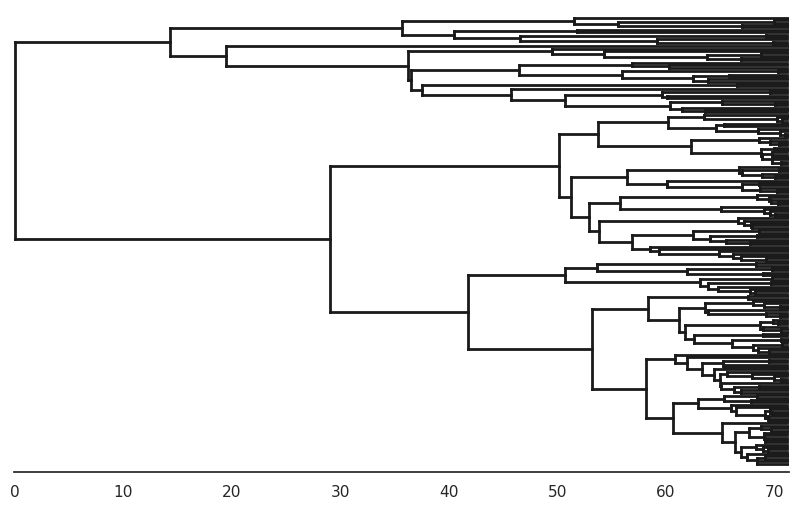

In [16]:
import baltic as bt

# Variation based on a gallery example
tree = bt.loadNewick("../data/trimmed_primate_tree.nwk")

tree.drawTree()
# Create a figure and axes
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_ylim(-3,tree.ySpan+3)
ax.set_xlim(-0.1,tree.treeHeight+0.1)
ax.set_yticks([])
ax.set_yticklabels([])

target_func=lambda k: k.is_leaf() ## which branches will be annotated
text_func=lambda k: "  "+k.name ## what text is plotted. Added two spaces, x_attr somehow fails
kwargs={'va':'center','ha':'left','size': 8} ## kwargs for text

#tree.addText(ax,target=target_func,text=text_func,**kwargs) ## text will use a different x attribute 


# Plot the tree
tree.plotTree(ax)
[ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']]
plt.show()

In [17]:
species_with_x_and_tree = species_with_x.loc[species_with_x["Binomial name"].isin(trimmed_list)]
species_with_x_and_tree['Binomial name'] = pd.Categorical(species_with_x_and_tree['Binomial name'], categories=trimmed_list, ordered=True)

/tmp/24930299/ipykernel_3681308/3840624021.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  species_with_x_and_tree['Binomial name'] = pd.Categorical(species_with_x_and_tree['Binomial name'], categories=trimmed_list, ordered=True)


In [18]:
species_with_x_and_tree.sort_values(["Binomial name"])

chr_type,index,species,aut,chrX,CV_aut,Autosomal Pi per base,ChrX Pi per base,X_a_ratio,X/A ratio,binomial_name,strategy,Binomial name
129,161,Pan_troglodytes_ssp,175.912882,121.458122,0.478890,0.001759,0.001215,0.690445,0.690445,Pan_troglodytes,Polygynandrous,Pan troglodytes
128,160,Pan_paniscus_ssp,84.004908,56.046564,0.613750,0.000840,0.000560,0.667182,0.667182,Pan_paniscus,Polygynandrous,Pan paniscus
73,90,Gorilla_gorilla_ssp,189.796965,105.613349,0.625608,0.001898,0.001056,0.556454,0.556454,Gorilla_gorilla,Polygynous,Gorilla gorilla
72,89,Gorilla_beringei_ssp,113.030773,51.270695,0.785494,0.001130,0.000513,0.453599,0.453599,Gorilla_beringei,Polygynous,Gorilla beringei
150,190,Pongo_pygmaeus_ssp,191.469580,69.489692,0.587609,0.001915,0.000695,0.362928,0.362928,Pongo_pygmaeus,Polygynous,Pongo pygmaeus
...,...,...,...,...,...,...,...,...,...,...,...,...
70,87,Galago_senegalensis_ssp,331.648304,203.714097,0.382056,0.003316,0.002037,0.614247,0.614247,Galago_senegalensis,Polygynous,Galago senegalensis
69,86,Galago_moholi_ssp,165.330197,71.717073,0.655587,0.001653,0.000717,0.433781,0.433781,Galago_moholi,Polygynous,Galago moholi
127,159,Otolemur_garnettii_ssp,224.790228,121.140759,0.582165,0.002248,0.001211,0.538906,0.538906,Otolemur_garnettii,conflicting,Otolemur garnettii
126,158,Otolemur_crassicaudatus_ssp,160.755154,114.307077,0.430408,0.001608,0.001143,0.711063,0.711063,Otolemur_crassicaudatus,Polygynous,Otolemur crassicaudatus


In [19]:
covariance_matrix = pd.read_csv("../data/trimmed_cov.csv", header=None)
covariance_matrix

,0,1,2,3,4,5,6,7,8,9,...,180,181,182,183,184,185,186,187,188,189
0,71.23,19.42,19.42,19.42,19.42,19.42,19.42,19.42,19.42,19.42,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,19.42,71.22,60.09,59.67,59.67,50.70,50.70,50.70,50.70,50.70,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,19.42,60.09,71.22,59.67,59.67,50.70,50.70,50.70,50.70,50.70,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,19.42,59.67,59.67,71.22,69.63,50.70,50.70,50.70,50.70,50.70,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,19.42,59.67,59.67,69.63,71.22,50.70,50.70,50.70,50.70,50.70,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,60.19,60.19,60.19,60.19,70.97,71.24,70.51,68.47,64.66,64.66
186,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,60.19,60.19,60.19,60.19,70.51,70.51,71.24,68.47,64.66,64.66
187,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,60.19,60.19,60.19,60.19,68.47,68.47,68.47,71.23,64.66,64.66
188,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,60.19,60.19,60.19,60.19,64.66,64.66,64.66,64.66,71.24,65.39


In [20]:
species_with_x_and_tree

chr_type,index,species,aut,chrX,CV_aut,Autosomal Pi per base,ChrX Pi per base,X_a_ratio,X/A ratio,binomial_name,strategy,Binomial name
0,0,Allenopithecus_nigroviridis_ssp,137.982459,75.953318,0.429676,0.001380,0.000760,0.550456,0.550456,Allenopithecus_nigroviridis,Polygynandrous,Allenopithecus nigroviridis
1,1,Allochrocebus_lhoesti_ssp,270.545488,95.879342,0.515777,0.002705,0.000959,0.354393,0.354393,Allochrocebus_lhoesti,Polygynous,Allochrocebus lhoesti
2,2,Allochrocebus_preussi_ssp,264.111020,103.444526,0.701331,0.002641,0.001034,0.391671,0.391671,Allochrocebus_preussi,Polygynous,Allochrocebus preussi
3,4,Alouatta_belzebul_ssp,514.466060,372.814073,0.266829,0.005145,0.003728,0.724662,0.724662,Alouatta_belzebul,Polygynous,Alouatta belzebul
4,6,Alouatta_discolor_ssp,203.027011,107.542809,0.604936,0.002030,0.001075,0.529697,0.529697,Alouatta_discolor,Polygynous,Alouatta discolor
...,...,...,...,...,...,...,...,...,...,...,...,...
188,245,Trachypithecus_pileatus_ssp,110.639320,61.087930,0.762625,0.001106,0.000611,0.552136,0.552136,Trachypithecus_pileatus,Polygynous,Trachypithecus pileatus
189,246,Trachypithecus_poliocephalus_ssp,64.668560,37.579588,0.712469,0.000647,0.000376,0.581111,0.581111,Trachypithecus_poliocephalus,conflicting,Trachypithecus poliocephalus
190,247,Trachypithecus_vetulus_ssp,231.916027,137.574031,0.430623,0.002319,0.001376,0.593206,0.593206,Trachypithecus_vetulus,conflicting,Trachypithecus vetulus
191,249,Varecia_variegata_ssp,211.166648,119.902105,0.422388,0.002112,0.001199,0.567808,0.567808,Varecia_variegata,conflicting,Varecia variegata


In [21]:
import statsmodels.formula.api as smf
glm_results = smf.gls(formula = "X_a_ratio ~ aut*CV_aut", sigma=covariance_matrix,
                      data=species_with_x_and_tree.sort_values(["Binomial name"])).fit()
glm_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:              X_a_ratio   R-squared:                       0.208
Model:                            GLS   Adj. R-squared:                  0.195
Method:                 Least Squares   F-statistic:                     16.26
Date:                Tue, 17 Feb 2026   Prob (F-statistic):           1.98e-09
Time:                        09:01:59   Log-Likelihood:                 98.759
No. Observations:                 190   AIC:                            -189.5
Df Residuals:                     186   BIC:                            -176.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5466      0.224      2.437      0.016       0.104       0.989
aut            0.0007      0.000      4.567      0.000       0.000       0.001
CV_aut        -0.0123      0.038     -0.322      0.748      -0.088       0.063
aut:CV_aut    -0.0014      0.000     -4.121      0.000      -0.002      -0.001
==============================================================================
Omnibus:                       58.407   Durbin-Watson:                   1.967
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              433.051
Skew:                          -0.905   Prob(JB):                     9.21e-95
Kurtosis:                      10.171   Cond. No.                     4.24e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.24e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

I also performed the regression in caper with a kappa of 2. R-square there was 0.31.
However, it cannot include the sample weights. On the other hand, as I show below, the distribution of values for rare/common species are similar.

In [22]:
s_count = []
for s in species_with_x_and_tree.species:
    s_count.append(len(metadata_20x_filt.loc[metadata_20x_filt.species_genotyping == s]))
species_with_x_and_tree["sample_count"] = s_count

/tmp/24930299/ipykernel_3681308/3348411378.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  species_with_x_and_tree["sample_count"] = s_count


In [23]:
species_with_x_and_tree.sort_values(["Binomial name"]).sample_count

129    94
128    15
73     29
72     20
150    16
       ..
70      2
69      2
127     3
126     2
71      1
Name: sample_count, Length: 190, dtype: int64

<Axes: xlabel='sample_count', ylabel='X_a_ratio'>

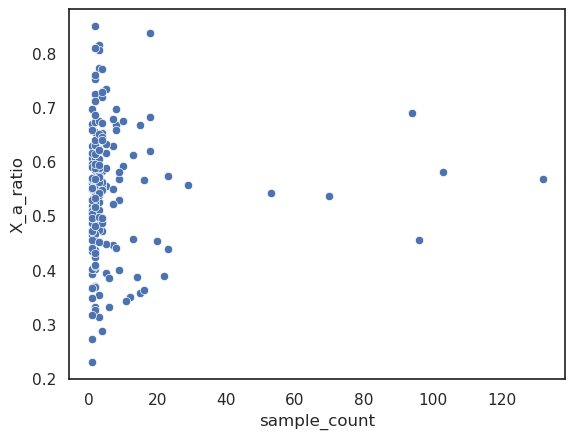

In [24]:
sns.scatterplot(species_with_x_and_tree, x="sample_count", y="X_a_ratio")

In [25]:
species_with_x_and_tree.sample_count.median()

2.5

<Axes: xlabel='X_a_ratio', ylabel='Count'>

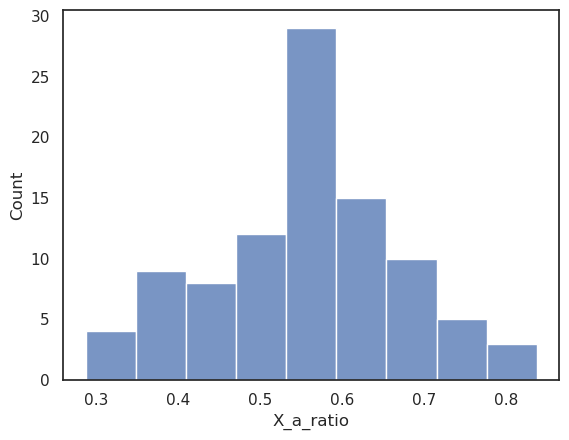

In [26]:
sns.histplot(species_with_x_and_tree.loc[species_with_x_and_tree.sample_count >= 3], x="X_a_ratio")

<Axes: xlabel='X_a_ratio', ylabel='Count'>

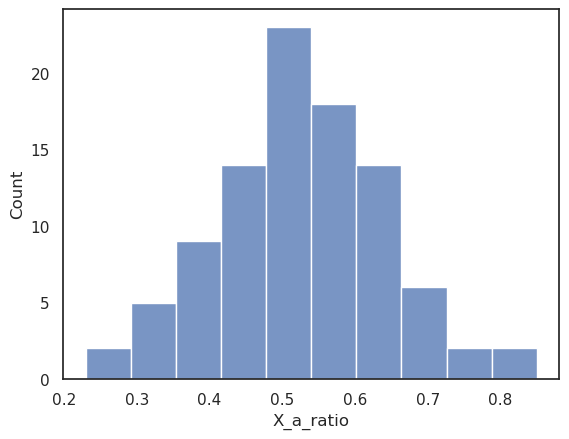

In [27]:
sns.histplot(species_with_x_and_tree.loc[species_with_x_and_tree.sample_count < 3], x="X_a_ratio")

In [28]:
species_with_x_and_tree.loc[species_with_x_and_tree.sample_count >= 3].X_a_ratio.mean(), species_with_x_and_tree.loc[species_with_x_and_tree.sample_count < 3].X_a_ratio.mean()

(0.5571484761938634, 0.5262202274690687)

In [29]:
species_with_x_and_tree.loc[species_with_x_and_tree.sample_count >= 3].X_a_ratio.var(), species_with_x_and_tree.loc[species_with_x_and_tree.sample_count < 3].X_a_ratio.var()

(0.013633993821977424, 0.013504433648629986)

In [30]:
glm_results = smf.gls(formula = "X_a_ratio ~ aut*CV_aut", sigma=covariance_matrix,# weights=np.sqrt(species_with_x_and_tree.sort_values(["Binomial name"]).sample_count),
                      data=species_with_x_and_tree.sort_values(["Binomial name"])).fit()
glm_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:              X_a_ratio   R-squared:                       0.208
Model:                            GLS   Adj. R-squared:                  0.195
Method:                 Least Squares   F-statistic:                     16.26
Date:                Tue, 17 Feb 2026   Prob (F-statistic):           1.98e-09
Time:                        09:02:00   Log-Likelihood:                 98.759
No. Observations:                 190   AIC:                            -189.5
Df Residuals:                     186   BIC:                            -176.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5466      0.224      2.437      0.016       0.104       0.989
aut            0.0007      0.000      4.567      0.000       0.000       0.001
CV_aut        -0.0123      0.038     -0.322      0.748      -0.088       0.063
aut:CV_aut    -0.0014      0.000     -4.121      0.000      -0.002      -0.001
==============================================================================
Omnibus:                       58.407   Durbin-Watson:                   1.967
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              433.051
Skew:                          -0.905   Prob(JB):                     9.21e-95
Kurtosis:                      10.171   Cond. No.                     4.24e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.24e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [44]:
glm_results = smf.gls(formula = "X_a_ratio ~ aut*CV_aut+aut:strategy", sigma=covariance_matrix,
                      data=species_with_x_and_tree.sort_values(["Binomial name"])).fit()
glm_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:              X_a_ratio   R-squared:                       0.340
Model:                            GLS   Adj. R-squared:                  0.315
Method:                 Least Squares   F-statistic:                     13.42
Date:                Tue, 17 Feb 2026   Prob (F-statistic):           6.35e-14
Time:                        09:12:33   Log-Likelihood:                 116.16
No. Observations:                 190   AIC:                            -216.3
Df Residuals:                     182   BIC:                            -190.3
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==================================================================================================
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                          0.5471      0.207      2.640      0.009       0.138       0.956
aut                                0.0006      0.000      3.528      0.001       0.000       0.001
aut:strategy[T.Polyandrous]    -6.432e-05      0.000     -0.473      0.637      -0.000       0.000
aut:strategy[T.Polygynandrous]     0.0002      0.000      1.651      0.101   -3.73e-05       0.000
aut:strategy[T.Polygynous]        -0.0001      0.000     -1.178      0.240      -0.000     8.2e-05
aut:strategy[T.conflicting]        0.0002   9.36e-05      2.401      0.017    4.01e-05       0.000
CV_aut                            -0.0124      0.035     -0.352      0.725      -0.082       0.057
aut:CV_aut                        -0.0013      0.000     -3.976      0.000      -0.002      -0.001
==============================================================================
Omnibus:                       14.869   Durbin-Watson:                   2.014
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               38.701
Skew:                           0.211   Prob(JB):                     3.95e-09
Kurtosis:                       5.170   Cond. No.                     5.34e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.34e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [32]:
import statsmodels.api as sm
X = sm.add_constant(species_with_x_and_tree.aut)
wls_model = sm.GLS(species_with_x_and_tree.X_a_ratio, X)
results = wls_model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:              X_a_ratio   R-squared:                       0.000
Model:                            GLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                   0.07614
Date:                Tue, 17 Feb 2026   Prob (F-statistic):              0.783
Time:                        09:02:00   Log-Likelihood:                 138.26
No. Observations:                 190   AIC:                            -272.5
Df Residuals:                     188   BIC:                            -266.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5379      0.016     33.272      0.000       0.506       0.570
aut         1.779e-05   6.45e-05      0.276      0.783      -0.000       0.000
==============================================================================
Omnibus:                        0.024   Durbin-Watson:                   1.743
Prob(Omnibus):                  0.988   Jarque-Bera (JB):                0.014
Skew:                           0.012   Prob(JB):                        0.993
Kurtosis:                       2.965   Cond. No.                         476.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [33]:
X = sm.add_constant(species_with_x_and_tree.aut)
wls_model = sm.WLS(species_with_x_and_tree.X_a_ratio, X,
                   weights=species_with_x_and_tree.sample_count)
results = wls_model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:              X_a_ratio   R-squared:                       0.000
Model:                            WLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                   0.08227
Date:                Tue, 17 Feb 2026   Prob (F-statistic):              0.775
Time:                        09:02:00   Log-Likelihood:                 81.535
No. Observations:                 190   AIC:                            -159.1
Df Residuals:                     188   BIC:                            -152.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5466      0.018     30.372      0.000       0.511       0.582
aut         2.061e-05   7.18e-05      0.287      0.775      -0.000       0.000
==============================================================================
Omnibus:                       35.731   Durbin-Watson:                   1.847
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              207.980
Skew:                           0.470   Prob(JB):                     6.88e-46
Kurtosis:                       8.039   Cond. No.                         587.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [34]:
sorted_filtered = species_with_x_and_tree.loc[species_with_x_and_tree.sample_count >= 2]

In [35]:
glm_results = smf.gls(formula = "X_a_ratio ~ aut*CV_aut", 
                      weights=np.sqrt(sorted_filtered.sort_values(["Binomial name"]).sample_count),
                      data=sorted_filtered.sort_values(["Binomial name"])).fit()
glm_results.summary()

/home/eriks/miniconda3/envs/primatediversity2/lib/python3.12/site-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['weights']
  warnings.warn(msg, ValueWarning)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:              X_a_ratio   R-squared:                       0.610
Model:                            GLS   Adj. R-squared:                  0.602
Method:                 Least Squares   F-statistic:                     75.16
Date:                Tue, 17 Feb 2026   Prob (F-statistic):           2.58e-29
Time:                        09:02:00   Log-Likelihood:                 116.51
No. Observations:                 148   AIC:                            -225.0
Df Residuals:                     144   BIC:                            -213.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6509      0.042     15.458      0.000       0.568       0.734
aut            0.0004      0.000      1.768      0.079   -4.28e-05       0.001
CV_aut        -0.0869      0.054     -1.600      0.112      -0.194       0.020
aut:CV_aut    -0.0013      0.000     -2.527      0.013      -0.002      -0.000
==============================================================================
Omnibus:                        0.725   Durbin-Watson:                   1.210
Prob(Omnibus):                  0.696   Jarque-Bera (JB):                0.737
Skew:                           0.165   Prob(JB):                        0.692
Kurtosis:                       2.896   Cond. No.                     1.91e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.91e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [36]:
np.sqrt(sorted_filtered.sort_values(["Binomial name"]).sample_count)

129    9.695360
128    3.872983
73     5.385165
72     4.472136
150    4.000000
         ...   
136    1.414214
70     1.414214
69     1.414214
127    1.732051
126    1.414214
Name: sample_count, Length: 148, dtype: float64